<a href="https://colab.research.google.com/github/Carmen10-171/03MIAR_Algoritmos-de-Optimizacion/blob/main/Ponencia_Parte_0_Calentamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ¿Qué es la optimización?




* Encontrar los mejores parámetros que hacen que un modelo aprenda correctamente
* Usar técnicas para llegar a converger de una manera más eficiente
* Siempre tratamos de minimizar o maximizar algún punto del proceso:
  * Ejemplo: Minimizar el error al predecir
  * Ejemplo: Maximizar la precisión de un modelo
  * Ejemplo: Minimizar la distancia entre puntos de un mismo grupo (clustering)




# Carga de librerias

In [1]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Inicio, enfoque clásico

In [2]:
# Cargar y preparar el dataset
iris = load_iris(as_frame=True)
df = iris.frame
# Vamos a ver el dataset
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# ¿Cuántas clases/variables tengo? ¿1? ¿2? ¿3?
# Según el número de clases/variables representativas debo escoger una representación.
# Si estáis empezando, más de 3 clases puede ser un problema.
# A la hora de representar cada clase equivale a una dimensión.
# Si tengo 2 dimensiones, ¿qué puedo usar?, ¿Y con 3 dimensiones?
# ¿Y si quiero reducir dimensiones?

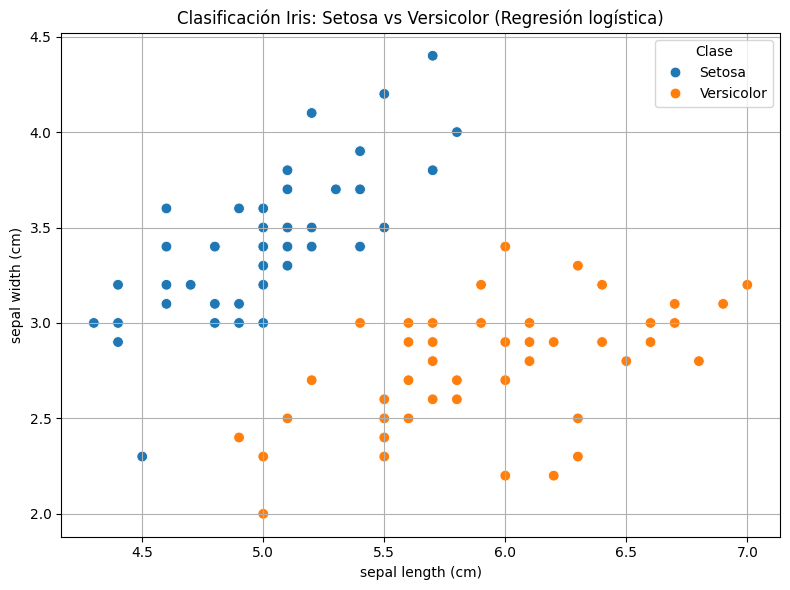

In [4]:
# En nuestro caso, tenemos 3 clases.
# Si quiero, puedo seleccionar una clase en concreto y agrupar el resto.
# Dos variables = Plano X/Y
# Filtrar solo Setosa (0) y Versicolor (1)
df = df[df['target'].isin([0, 1])]

# Seleccionar dos características para visualización
# PREGUNTA: ¿Por qué selecciono estos dos atributos?
# PISTA: MIRAD LOS DATOS
features = ['sepal length (cm)', 'sepal width (cm)']
X = df[features].values
y = df['target'].values

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Entrenar modelo de regresión logística
model = LogisticRegression()
model.fit(X_train, y_train)

# Visualizar puntos
# Convertimos los valores numéricos a nombres de clase
y_labels = ['Setosa' if label == 0 else 'Versicolor' for label in y]

# Dibujamos el gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_labels, palette={'Setosa': '#1f77b4', 'Versicolor': '#ff7f0e'}, s=60)
plt.title("Clasificación Iris: Setosa vs Versicolor (Regresión logística)")
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend(title='Clase')
plt.grid(True)
plt.tight_layout()
plt.show()

# VISUALIZAR LOS DATOS ES MUY IMPORTANTE PARA ENTENDER CÓMO FUNCIONA EL MODELO
# ¿SOIS CAPACES DE TRAZAR UNA LÍNEA RECTA PARA SEPARAR LOS DATOS?

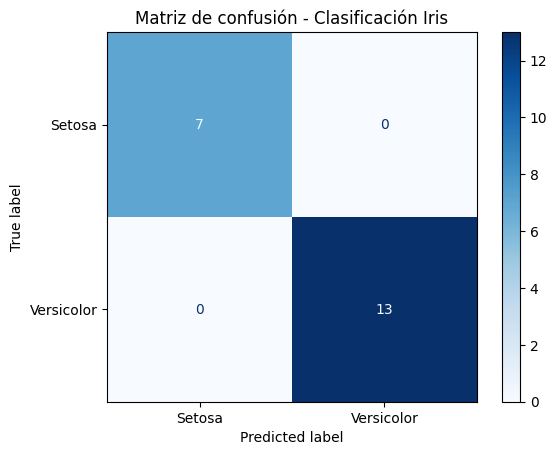

In [5]:
# Hemos acabado el entrenamiento
# Vamos a predecir
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predecir sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz de confusión con etiquetas de clase
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Setosa', 'Versicolor'])
disp.plot(cmap='Blues')
plt.title("Matriz de confusión - Clasificación Iris")
plt.grid(False)
plt.show()

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Mostrar resultados
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")


Accuracy:  1.00
Precision: 1.00
Recall:    1.00
F1 Score:  1.00


In [7]:
# ¿Hay que mejorar algo?
# ¿Qué ocurre?
# ¿Está mal?

# ¿Podemos cambiar el enfoque? ¿Y si damos menos datos?

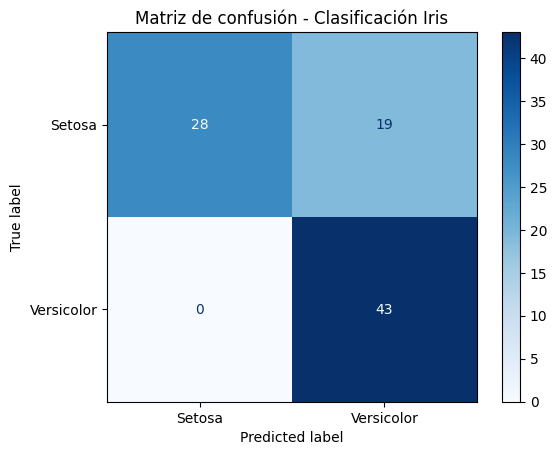

In [8]:
# División en entrenamiento y prueba
# ANTES:
# ENTRENAS: 80%
# TEST: 20%
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# AHORA:
# ENTRENAS: 10%
# TEST: 90%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9, random_state=2025)

# Entrenar modelo de regresión logística
model = LogisticRegression()
model.fit(X_train, y_train)

# Predecir sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz de confusión con etiquetas de clase
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Setosa', 'Versicolor'])
disp.plot(cmap='Blues')
plt.title("Matriz de confusión - Clasificación Iris")
plt.grid(False)
plt.show()

In [9]:
# ¿Cómo podemos optimizar usando el entrenamiento?
# ¿Entrenando el modelo con más datos? ¿Es siempre mejor?
# ¿70-30? ¿80-20? ¿KFOLD? Ojo, con el 70% de entrenamiento ya tenemos unos resultados perfectos.


In [10]:
# ¿Podemos mejorar usando la representación gráfica?

# Gradiente Estocástico - Representación gráfica

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


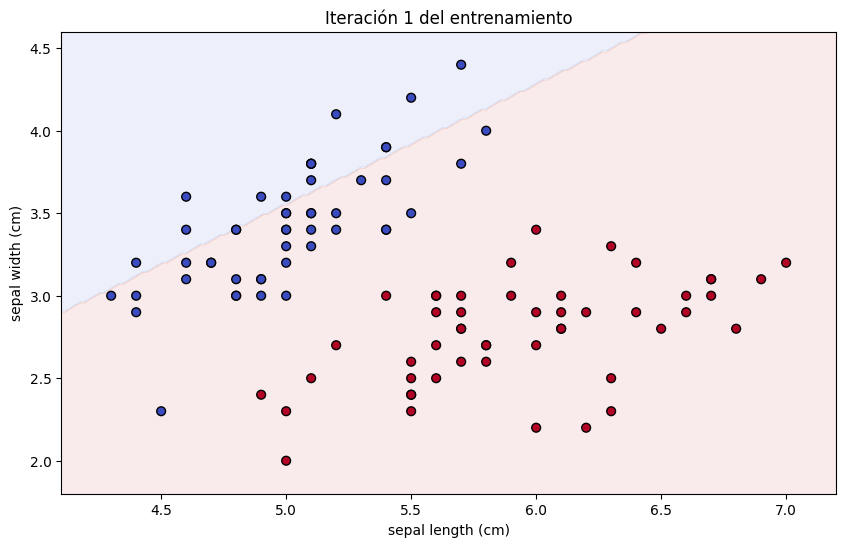

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


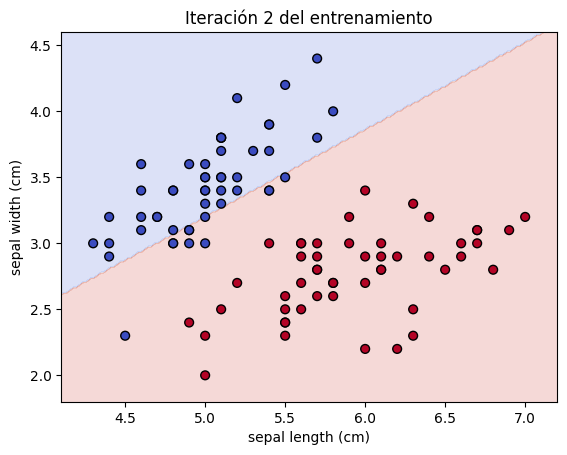

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


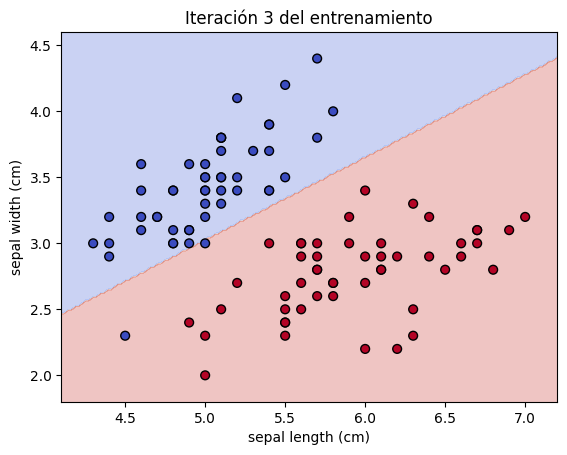

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


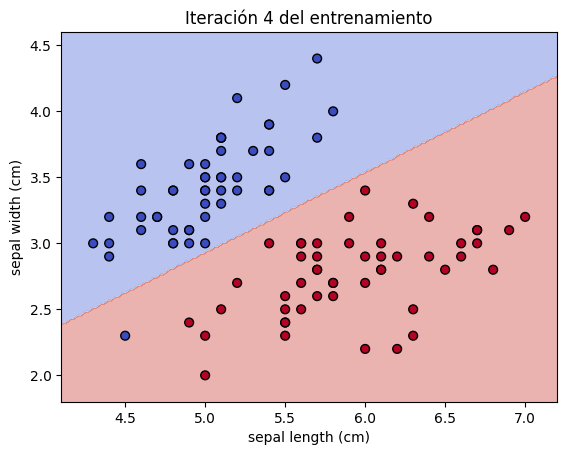

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


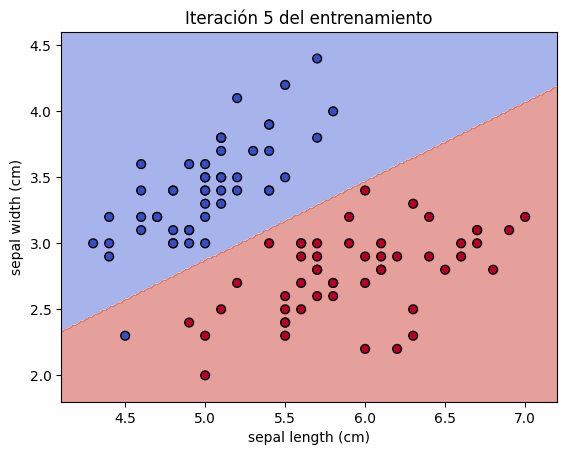

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


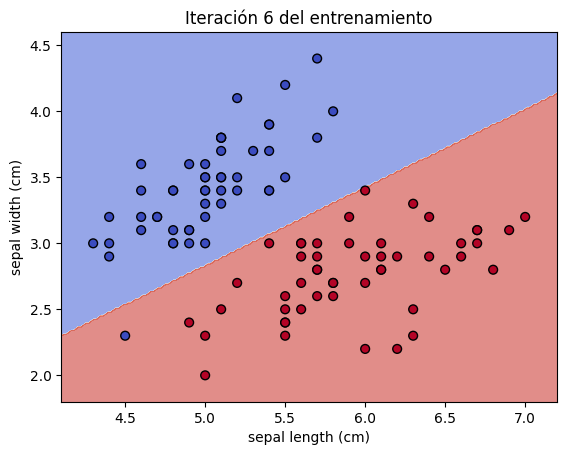

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


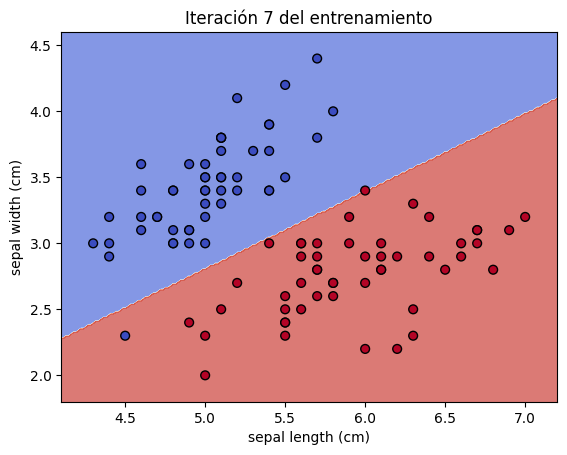

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


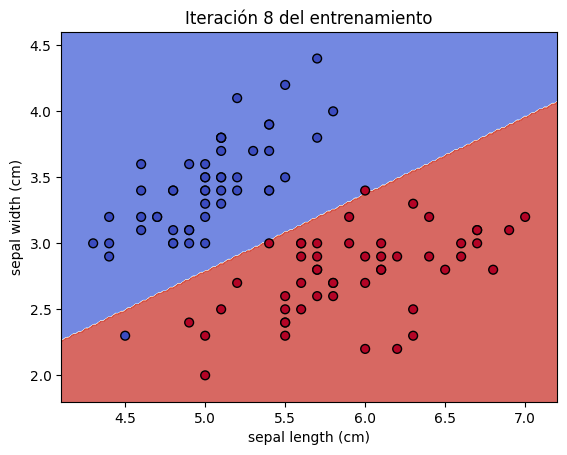

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


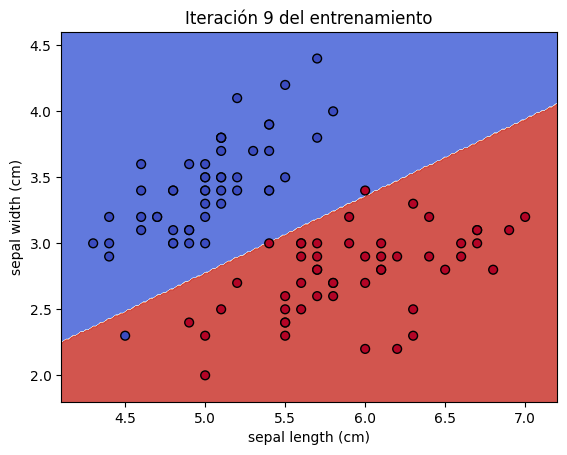

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


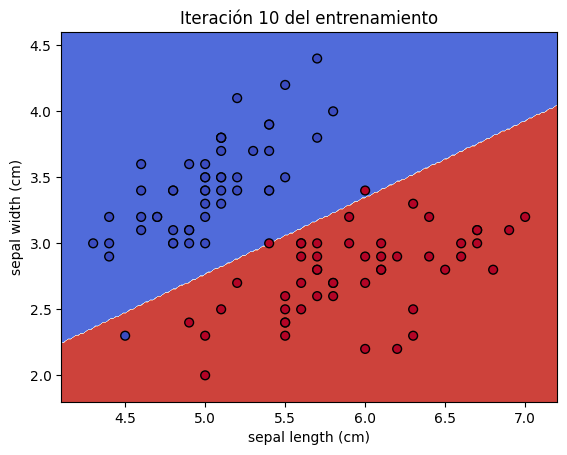

<Figure size 640x480 with 0 Axes>

In [11]:
# Importamos librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier

# Modelo SGD = Stochastic Gradient Descent (Descenso de gradiente estocástico)

# Es un algoritmo de clasificación.
# La función de pérdida medirá qué tan mal está está actuando el modelo.
# El objetivo es minimizar el error.


# Es una forma de optimizar que actualiza los parámetros usando solo algunos ejemplos a la vez
# Es más rápido y funciona bien con grandes cantidades de datos


# Creamos el modelo
model = SGDClassifier(
    loss='log_loss',          # Función de pérdida: log_loss
    learning_rate='constant', # Tipo de tasa de aprendizaje (puede ser constante o adaptativa)
    eta0=0.1,                 # Tasa de aprendizaje (cuánto ajusta en cada paso)
    max_iter=1,               # Solo 1 iteración por llamada a fit()
    warm_start=True,          # Conserva el estado entre llamadas a fit() (no reinicia)
    random_state=2025
)

# Creamos los datos
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)
df = iris.frame

# Nos quedamos con solo 2 clases (Setosa y Versicolor)
df = df[df['target'].isin([0, 1])]
features = ['sepal length (cm)', 'sepal width (cm)']
X = df[features].values
y = df['target'].values

# Separación en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Visualización del aprendizaje paso a paso
plt.figure(figsize=(10, 6))

# Repetimos el entrenamiento por pasos
# 10 iteraciones
for i in range(10):
    # Ajusta una sola vez cada vuelta (gracias a max_iter=1)
    model.fit(X_train, y_train)
    # Creamos una malla de puntos para pintar la frontera de decisión
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predecimos sobre la malla para ver la frontera
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Pintamos la frontera de decisión (zonas de cada clase)
    plt.contourf(xx, yy, Z, alpha=0.1*(i+1), cmap='coolwarm')

    # Dibujamos los datos
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=40)
    plt.title(f"Iteración {i+1} del entrenamiento")
    plt.xlabel(features[0])
    plt.ylabel(features[1])
    # Pausa para que se vea el cambio
    plt.pause(1)

# Mostrar resultado final
plt.tight_layout()
plt.show()


# ¿Y si usamos todas las clases?

In [ ]:
import plotly.express as px
from sklearn.datasets import load_iris
import pandas as pd

# Cargar el dataset completo
iris = load_iris(as_frame=True)
df = iris.frame

# Añadir etiquetas de clase con nombres
df['class'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

# Seleccionar tres características para las dimensiones
fig = px.scatter_3d(
    df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    z='petal length (cm)',
    color='class',
    symbol='class',
    title='Clasificación 3D: Setosa, Versicolor y Virginica',
    width=900,
    height=700
)

fig.update_traces(marker=dict(size=6))
fig.show()


In [ ]:
# Vamos a optimizar el modelo
# Centrémonos en esta parte:

# Creamos el modelo
"""
model = SGDClassifier(
    loss='log_loss',          # Función de pérdida: log_loss
    learning_rate='constant', # Tipo de tasa de aprendizaje (puede ser constante o adaptativa)
    eta0=0.1,                 # Tasa de aprendizaje (cuánto ajusta en cada paso)
    max_iter=1,               # Solo 1 iteración por llamada a fit()
    warm_start=True,          # Conserva el estado entre llamadas a fit() (no reinicia)
    random_state=2025
)

# loss = función de pérdida, mide qué tan mal está el modelo
# En clasificación, log_loss mide la diferencia entre la predicción y la etiqueta real
# Es decir, define qué tipo de problema estamos resolviendo
# El objetivo es minimizar esa pérdida
# También sirve para señalar cómo penalizamos los errores que comete el modelo
# ¿Cómo sabemos qué opción tenemos que elegir?


Log Loss en una clasificación:

¿Quieres que tu modelo elija entre varias opciones (por ejemplo, “sí” o “no”)?
  Sí, dado que vas a hacer clasificación
  No, vas a hacer una regresión
    ¿Te interesa que el modelo dé una probabilidad (por ejemplo, 80% de que sea “sí”)?
      Sí
        Usa 'log_loss' (regresión logística)
      No
        ¿Te importa que el modelo separe bien las clases con un “margen de seguridad”?
          Sí
            Usa 'hinge' (como un SVM)
          No
            ¿Crees que tus datos pueden tener errores o casos extraños?
              Sí,
                Usa 'modified_huber' (es más tolerante al ruido)
              No
                Usa 'hinge'


Log Loss en una regresión:

¿Te importa que los errores sean lo más pequeños posibles?
  Sí
    Usa 'squared_error' (regresión clásica)
  No
    ¿Te da igual si el modelo se equivoca un poco (mientras no sea mucho)?
      Sí
        Usa 'epsilon_insensitive' (solo castiga los errores grandes)
      No
        Usa 'squared_error'
"""

"\nmodel = SGDClassifier(\n    loss='log_loss',          # Función de pérdida: log_loss\n    learning_rate='constant', # Tipo de tasa de aprendizaje (puede ser constante o adaptativa)\n    eta0=0.1,                 # Tasa de aprendizaje (cuánto ajusta en cada paso)\n    max_iter=1,               # Solo 1 iteración por llamada a fit()\n    warm_start=True,          # Conserva el estado entre llamadas a fit() (no reinicia)\n    random_state=2025\n)\n\n# loss = función de pérdida, mide qué tan mal está el modelo\n# En clasificación, log_loss mide la diferencia entre la predicción y la etiqueta real\n# Es decir, define qué tipo de problema estamos resolviendo\n# El objetivo es minimizar esa pérdida\n# También sirve para señalar cómo penalizamos los errores que comete el modelo\n# ¿Cómo sabemos qué opción tenemos que elegir?\n\n\nLog Loss en una clasificación:\n\n¿Quieres que tu modelo elija entre varias opciones (por ejemplo, “sí” o “no”)?\n  Sí, dado que vas a hacer clasificación\n  No, v

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
import numpy as np
import pandas as pd

# Cargar dataset Iris (Setosa vs Versicolor)
iris = load_iris(as_frame=True)
df = iris.frame
X = df[['sepal length (cm)', 'sepal width (cm)']].values
y = df['target'].values

# Separación 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Diferentes funciones de pérdida a comparar
modelos = {
    'log_loss': SGDClassifier(loss='log_loss', max_iter=1000, random_state=2025),
    'hinge': SGDClassifier(loss='hinge', max_iter=1000, random_state=2025),
    'modified_huber': SGDClassifier(loss='modified_huber', max_iter=1000, random_state=2025),
    'perceptron': SGDClassifier(loss='perceptron', max_iter=1000, random_state=2025)
}

# Evaluar cada modelo
resultados = []

for nombre, model in modelos.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    try:
        proba = model.predict_proba(X_test)
        loss = log_loss(y_test, proba)
    except:
        loss = None

    resultados.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Log Loss': loss
    })

# Mostrar resultados
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

# ================================
# ¿Qué podemos ver?
# ================================

# 1. El modelo 'perceptron' tiene la mayor accuracy (0.80), pero no da probabilidades.
#    Por eso no podemos calcular log_loss (sale NaN).
#    Es útil si solo te importa acertar, no saber cuán seguro está el modelo.

# 2. 'log_loss' da buena accuracy (0.66) pero log_loss muy alto.
#    Esto sugiere que las probabilidades que devuelve son malas o poco seguras.

# 3. 'modified_huber' tiene menor accuracy (0.60) pero mejor log_loss (2.91).

# 4. 'hinge' actúa como un SVM. Da buena accuracy (0.63), pero tampoco ofrece probabilidades.
#    Tampoco podemos comparar su log_loss.

# En resumen:
# - Usa 'perceptron' si quieres simplicidad y solo importa acertar.
# - Usa 'log_loss' si quieres probabilidades (aunque aquí salieron poco fiables).
# - Usa 'modified_huber' si crees que los datos tienen ruido o casos raros.
# - 'hinge' es como un SVM: útil si quieres separar con margen, pero sin probabilidades.

           Modelo  Accuracy  Log Loss
0        log_loss  0.666667  4.774008
1           hinge  0.633333       NaN
2  modified_huber  0.600000  2.915596
3      perceptron  0.800000       NaN


In [ ]:
"""
Learning Rate o Tasa de aprendizaje

Vamos a centrarnos en los parámetros:
  learning_rate='constant',
  eta0=0.1,

El aprendizaje lo marca la variable eta0
Si lanzas el modelo con un alto valor, no es capaz de aprender los detalles de cada clase (eta0=1)
Si lo lanzas con muy poca fuerza (eta0 muy bajo), nunca llega a acabar o toma muchas iteraciones en hacerlo (eta0=0.01)
Si vas ajustando de forma adecuada, mejora poco a poco (eta0=0.1)
¿Es constante ese valor siempre?
* No, no siempre conviene usar ese mismo valor todo el rato
* A veces conviene empezar rápido y luego ir más despacio
* La función de aprendizaje nos ayuda en este proceso según nuestras necesidades.
* ¿Cuál debo usar en cada momento? ¿Varía?


¿Quiero que eta0 se mantenga igual todo el tiempo?
    Sí
      Usa 'constant'
    No
      ¿Prefiero que el modelo calcule automáticamente el mejor ritmo?
        Sí
          Usa 'optimal'
        No
          ¿Quiero que eta0 vaya bajando poco a poco con cada paso?
              Sí
                Usa 'invscaling'
              No
                ¿Solo quiero que baje eta0 si el modelo se estanca?
                    Sí
                      Usa 'adaptive'
                    No, vuelves al inicio
                      Usa 'constant'

"""

"\nLearning Rate o Tasa de aprendizaje\n\nVamos a centrarnos en los parámetros:\n  learning_rate='constant',\n  eta0=0.1,\n\nEl aprendizaje lo marca la variable eta0\nSi lanzas el modelo con un alto valor, no es capaz de aprender los detalles de cada clase (eta0=1)\nSi lo lanzas con muy poca fuerza (eta0 muy bajo), nunca llega a acabar o toma muchas iteraciones en hacerlo (eta0=0.01)\nSi vas ajustando de forma adecuada, mejora poco a poco (eta0=0.1)\n¿Es constante ese valor siempre?\n* No, no siempre conviene usar ese mismo valor todo el rato\n* A veces conviene empezar rápido y luego ir más despacio\n* La función de aprendizaje nos ayuda en este proceso según nuestras necesidades.\n* ¿Cuál debo usar en cada momento? ¿Varía?\n\n\n¿Quiero que eta0 se mantenga igual todo el tiempo?\n    Sí\n      Usa 'constant'\n    No\n      ¿Prefiero que el modelo calcule automáticamente el mejor ritmo?\n        Sí\n          Usa 'optimal'\n        No\n          ¿Quiero que eta0 vaya bajando poco a poc

In [ ]:
# ================================
# Comparación de tasa de aprendizaje con SGDClassifier (multiclase)
# ================================

from sklearn.linear_model import SGDClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
import pandas as pd

# Cargar el dataset completo con todas las clases (Setosa, Versicolor, Virginica)
iris = load_iris(as_frame=True)
X = iris.data.values
y = iris.target.values

# Dividir datos 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Lista de tipos de learning_rate y valores de eta0 para comparar
learning_rates = ['constant', 'optimal', 'invscaling', 'adaptive']
eta0_values = [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100]

# Entrenar y comparar resultados
resultados = []

for lr in learning_rates:
    for eta in eta0_values:
        if lr == 'optimal' and eta != 0.01:
            continue
        clf = SGDClassifier(
            loss='log_loss',
            max_iter=1000,
            random_state=2025,
            learning_rate=lr,
            eta0=eta
        )
        try:
            clf.fit(X_train, y_train)
            pred = clf.predict(X_test)
            proba = clf.predict_proba(X_test)

            acc = accuracy_score(y_test, pred)
            loss = log_loss(y_test, proba)

            resultados.append({
                'learning_rate': lr,
                'eta0': eta if lr != 'optimal' else 'auto',
                'accuracy': acc,
                'log_loss': loss
            })
        except ValueError as e:
            resultados.append({
                'learning_rate': lr,
                'eta0': eta if lr != 'optimal' else 'auto',
                'accuracy': None,
                'log_loss': None,
                'error': str(e)
            })

resultados_df = pd.DataFrame(resultados)
print(resultados_df)


   learning_rate   eta0  accuracy  log_loss                error
0       constant  0.001  0.933333  0.424042                  NaN
1       constant   0.01  0.933333  0.330378                  NaN
2       constant    0.1  0.933333  0.266612                  NaN
3       constant      1  0.833333  6.007276                  NaN
4       constant      5  0.900000  1.880404                  NaN
5       constant     10  0.833333  6.007276                  NaN
6       constant     20  0.833333  6.007276                  NaN
7       constant     50       NaN       NaN  Input contains NaN.
8       constant    100       NaN       NaN  Input contains NaN.
9        optimal   auto  0.933333  1.276435                  NaN
10    invscaling  0.001  0.166667  1.071049                  NaN
11    invscaling   0.01  0.833333  0.661408                  NaN
12    invscaling    0.1  0.933333  0.389030                  NaN
13    invscaling      1  0.900000  0.293716                  NaN
14    invscaling      5  

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_base.py:395: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_base.py:395: RuntimeWarning:

invalid value encountered in divide



In [ ]:
# ¿Cómo mejoro con la tasa de aprendizaje?
#  Con adaptive         0.01  0.933333    0.267308

In [ ]:
"""
Otros parámetros

Warm_start: Para cada iteración puedo decirle que el modelo parta desde cero, sin aprendizaje (False) o que vaya iterando poco a poco (True)
random_state = Semilla

"""

'\nOtros parámetros\n\nWarm_start: Para cada iteración puedo decirle que el modelo parta desde cero, sin aprendizaje (False) o que vaya iterando poco a poco (True)\nrandom_state = Semilla\n\n'

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Cargar dataset completo
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Entrenamiento paso a paso
model = SGDClassifier(
    loss='log_loss',
    learning_rate='adaptive',
    eta0=0.01,
    max_iter=1,
    warm_start=True,
    random_state=2025
)

# Vamos a entrenar el modelo 10 veces seguidas, acumulando el aprendizaje
for i in range(10):
    model.fit(X_train, y_train)
    print(f"Iteración {i+1} completada")

# Evaluación del modelo final
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
loss = log_loss(y_test, y_proba)

print("\nEvaluación del modelo final:")
print("Accuracy:", round(acc, 4))
print("Log Loss:", round(loss, 4))

# A tener en cuenta:
# warm_start=False: En cada llamada a fit() empieza desde cero.
# warm_start=True: Cada llamada mejora sobre la anterior.



Iteración 1 completada
Iteración 2 completada
Iteración 3 completada
Iteración 4 completada
Iteración 5 completada
Iteración 6 completada
Iteración 7 completada
Iteración 8 completada
Iteración 9 completada
Iteración 10 completada

Evaluación del modelo final:
Accuracy: 0.8333
Log Loss: 0.3603


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning:

Maximum number of ite

In [ ]:
"""
¿Por qué la evaluación ha sido peor tras 10 iteraciones?
warm_start=True acumula aprendizaje, pero si el valor de eta0 (tasa de aprendizaje) es demasiado alto, el modelo puede:
* Sobreajustarse a los datos de entrenamiento.
* No converger bien, porque los pasos son demasiado grandes.

IMPORTANTE:

max_iter=1 y repetir .fit() muchas veces no es igual que usar max_iter=10:
Con warm_start=True, el modelo sigue actualizando los pesos sin parar, pero no se revisa si ya está aprendiendo bien o si debería frenar.
Si usas warm_start=True y no ajustas bien eta0, el modelo puede terminar aprendiendo de forma desordenada.

¿Cómo lo mejoramos?
"""

'\n¿Por qué la evaluación ha sido peor tras 10 iteraciones?\nwarm_start=True acumula aprendizaje, pero si el valor de eta0 (tasa de aprendizaje) es demasiado alto, el modelo puede:\n* Sobreajustarse a los datos de entrenamiento.\n* No converger bien, porque los pasos son demasiado grandes.\n\nIMPORTANTE:\n\nmax_iter=1 y repetir .fit() muchas veces no es igual que usar max_iter=10:\nCon warm_start=True, el modelo sigue actualizando los pesos sin parar, pero no se revisa si ya está aprendiendo bien o si debería frenar.\nSi usas warm_start=True y no ajustas bien eta0, el modelo puede terminar aprendiendo de forma desordenada.\n\n¿Cómo lo mejoramos?\n'

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

# Cargar dataset
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Crear el modelo
model = SGDClassifier(
    loss='log_loss',
    learning_rate='adaptive',
    eta0=0.01,
    max_iter=1,
    warm_start=True,
    random_state=2025
)

# Entrenamiento paso a paso (1000 veces)
for i in range(50):
    model.fit(X_train, y_train)

# Evaluación final
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
loss = log_loss(y_test, y_proba)

print("\nEvaluación final del modelo mejorado:")
print("Accuracy:", round(acc, 4))
print("Log Loss:", round(loss, 4))



Evaluación final del modelo mejorado:
Accuracy: 0.9
Log Loss: 0.2937


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning:

Maximum number of ite

# Calentamiento listo, ¡vamos a por la siguiente parte!